# Conjugate Gradients
### MECH 559 - Systems Optimization - L06
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

Builds up the conjugate-gradient (CG) method exactly as the lecture does: $Q$-orthogonality first, then the exact $n$-step algorithm for a convex quadratic, then the Hessian-free nonlinear variants (Fletcher-Reeves, Polak-Ribiere) that make CG practical for large, non-quadratic problems.

## Learning objectives

By the end, students should be able to:

1. Construct a set of $Q$-orthogonal directions and verify $d_i^{\mathrm T}Qd_j=0$ for $i\neq j$.
2. Implement the linear CG algorithm for a convex QP and confirm it converges in exactly $n$ steps.
3. Compare CG's convergence speed against plain steepest descent on the same (ill-conditioned) quadratic.
4. Implement Hessian-free nonlinear CG (Fletcher-Reeves / Polak-Ribiere) and compare it against the lecture's Hessian-dependent generalization.

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import line_search

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49", "gd": "0.5"}


def numerical_gradient(func, x, h=1e-6):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    g = np.zeros_like(x)
    for i in range(len(x)):
        step = np.zeros_like(x)
        step[i] = h
        g[i] = (func(x + step) - func(x - step)) / (2 * h)
    return g


print(f"NumPy {np.__version__}; optional widgets available: {WIDGETS_AVAILABLE}")

NumPy 2.5.0; optional widgets available: True


---
## 1. $Q$-orthogonality

Two vectors $d_1,d_2$ are $Q$-orthogonal (for symmetric $Q$) if $d_1^{\mathrm T}Qd_2=0$. Starting from any basis (e.g. the coordinate vectors), a $Q$-orthogonal Gram-Schmidt process builds a full $Q$-orthogonal set.

In [3]:
def q_orthogonalize(vectors, Q):
    directions = []
    for v in vectors:
        v = np.asarray(v, dtype=float).copy()
        for d in directions:
            v -= (d @ Q @ v) / (d @ Q @ d) * d
        directions.append(v)
    return directions

Q = np.array([[8.0, -4.0], [-4.0, 5.0]])
print("Q positive definite?", np.all(np.linalg.eigvalsh(Q) > 0))

directions = q_orthogonalize([np.array([1.0, 0.0]), np.array([0.0, 1.0])], Q)
for i, di in enumerate(directions):
    for j, dj in enumerate(directions):
        print(f"d_{i}^T Q d_{j} = {di @ Q @ dj: .2e}" + ("  (Q-orthogonal!)" if i != j else "  (self)"))

Q positive definite? True
d_0^T Q d_0 =  8.00e+00  (self)
d_0^T Q d_1 =  0.00e+00  (Q-orthogonal!)
d_1^T Q d_0 =  0.00e+00  (Q-orthogonal!)
d_1^T Q d_1 =  3.00e+00  (self)


---
## 2. Linear CG for a convex QP converges in exactly $n$ steps

$$
\min_{\mathbf x} f(\mathbf x) = \tfrac12 \mathbf x^{\mathrm T}\mathbf Q\mathbf x - \mathbf b^{\mathrm T}\mathbf x, \qquad \mathbf Q \succ 0.
$$

> **Predict:** the Conjugate Directions Theorem says the exact-arithmetic algorithm reaches $\mathbf x^\ast$ after $n$ steps. For a 2-variable quadratic, how many CG iterations should that be?

CG converged in 2 steps (n=2 variables)
x* = [-0.125 -0.5  ], CG final = [-0.125 -0.5  ]
steepest descent (exact line search) needed 38 steps on the same problem
condition number of Q = 4.83


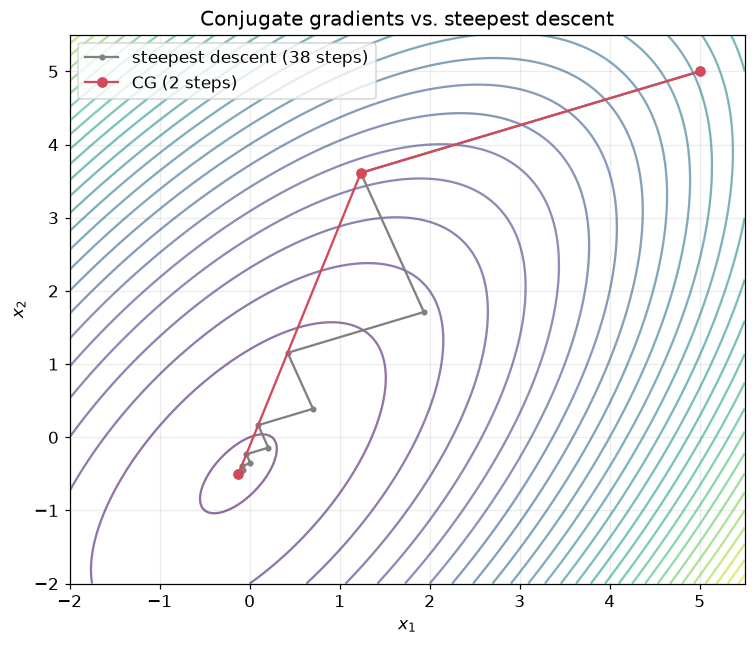

In [4]:
def cg_quadratic(Q, b, x0, tol=1e-12):
    x = np.array(x0, dtype=float)
    g = Q @ x - b
    d = -g
    traj = [x.copy()]
    for k in range(len(x) + 2):
        if g @ g < tol:
            break
        alpha = -(g @ d) / (d @ Q @ d)
        x = x + alpha * d
        g_new = Q @ x - b          # explicit "compute g_{k+1}" step
        if g_new @ g_new < tol:
            traj.append(x.copy())
            break
        beta = (g_new @ Q @ d) / (d @ Q @ d)
        d = -g_new + beta * d
        g = g_new
        traj.append(x.copy())
    return np.array(traj)

b = np.array([1.0, -2.0])
x_star = np.linalg.solve(Q, b)
traj_cg = cg_quadratic(Q, b, np.array([5.0, 5.0]))
print(f"CG converged in {len(traj_cg)-1} steps (n=2 variables)")
print(f"x* = {x_star}, CG final = {traj_cg[-1]}")

def gd_exact_quadratic(Q, b, x0, n_iter=200, tol=1e-12):
    x = np.array(x0, dtype=float)
    traj = [x.copy()]
    for _ in range(n_iter):
        g = Q @ x - b
        if g @ g < tol:
            break
        alpha = (g @ g) / (g @ Q @ g)
        x = x - alpha * g
        traj.append(x.copy())
    return np.array(traj)

traj_gd = gd_exact_quadratic(Q, b, np.array([5.0, 5.0]))
print(f"steepest descent (exact line search) needed {len(traj_gd)-1} steps on the same problem")
print(f"condition number of Q = {np.linalg.cond(Q):.2f}")

x1g, x2g = np.meshgrid(np.linspace(-2, 5.5, 200), np.linspace(-2, 5.5, 200))
Z = 0.5*(Q[0,0]*x1g**2 + 2*Q[0,1]*x1g*x2g + Q[1,1]*x2g**2) - (b[0]*x1g + b[1]*x2g)
fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(x1g, x2g, Z, levels=30, cmap="viridis", alpha=0.6)
ax.plot(traj_gd[:, 0], traj_gd[:, 1], "-o", color=COLORS["gd"], markersize=3, label=f"steepest descent ({len(traj_gd)-1} steps)")
ax.plot(traj_cg[:, 0], traj_cg[:, 1], "-o", color=COLORS["optimum"], markersize=6, label=f"CG ({len(traj_cg)-1} steps)")
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Conjugate gradients vs. steepest descent")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Nonlinear CG: Hessian-free (Fletcher-Reeves / Polak-Ribiere)

For general (non-quadratic) $f$, the standard, practical form of CG avoids the Hessian entirely: a (strong Wolfe) line search picks $\alpha_k$, and $\beta_k$ is computed from gradients only:
$$
\beta_k^{\text{FR}} = \frac{\|\mathbf g_{k+1}\|_2^2}{\|\mathbf g_k\|_2^2}, \qquad
\beta_k^{\text{PR}} = \max\!\left(0,\ \frac{\mathbf g_{k+1}^{\mathrm T}(\mathbf g_{k+1}-\mathbf g_k)}{\|\mathbf g_k\|_2^2}\right).
$$
This is why CG is attractive for large-scale problems: unlike Newton or the lecture's Hessian-based CG generalization (below), it never needs $H_k$.

In [5]:
def f_nl(x):
    x1, x2 = x
    return (1 - x1)**2 + (1 - x2)**2 + 0.5*(-x1**2 + 2*x2)**2

def grad_nl(x):
    return numerical_gradient(f_nl, x)

def nonlinear_cg_hessian_free(func, grad, x0, variant="FR", n_iter=200, tol=1e-8, restart=None):
    x = np.array(x0, dtype=float)
    g = grad(x)
    d = -g
    n = len(x)
    restart = restart or (n + 1)
    traj = [x.copy()]
    for k in range(n_iter):
        if np.linalg.norm(g) < tol:
            break
        alpha, *_ = line_search(func, grad, x, d, gfk=g, old_fval=func(x))
        if alpha is None:
            alpha = 1e-4
        x_new = x + alpha * d
        g_new = grad(x_new)
        if variant == "FR":
            beta = (g_new @ g_new) / (g @ g)
        else:
            beta = max(0.0, (g_new @ (g_new - g)) / (g @ g))
        if (k + 1) % restart == 0:
            beta = 0.0
        d = -g_new + beta * d
        x, g = x_new, g_new
        traj.append(x.copy())
    return np.array(traj)

traj_fr = nonlinear_cg_hessian_free(f_nl, grad_nl, [0.0, 0.0], variant="FR")
traj_pr = nonlinear_cg_hessian_free(f_nl, grad_nl, [0.0, 0.0], variant="PR")
print(f"Fletcher-Reeves: {len(traj_fr)-1} iterations, final={np.round(traj_fr[-1],4)}")
print(f"Polak-Ribiere:   {len(traj_pr)-1} iterations, final={np.round(traj_pr[-1],4)}")

Fletcher-Reeves: 11 iterations, final=[1.2134 0.8241]
Polak-Ribiere:   11 iterations, final=[1.2134 0.8241]


---
## 4. The lecture's Hessian-based nonlinear CG, for comparison

The slides also give a direct generalization that plugs the *actual* Hessian $H_k$ into the quadratic-CG formulas for $\alpha_k$ and $\beta_k$. It's a valid extension, and using full second-order information makes it converge in fewer iterations - but it defeats the main practical selling point of CG (avoiding Hessians), and it can fail if $H_k$ is not positive definite along $d_k$.

In [6]:
def numerical_hessian(func, x, h=1e-4):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            si = np.zeros(n); si[i] = h
            sj = np.zeros(n); sj[j] = h
            H[i, j] = (func(x + si + sj) - func(x + si - sj) - func(x - si + sj) + func(x - si - sj)) / (4 * h**2)
    return H

def nonlinear_cg_hessian_based(func, x0, n_iter=50, tol=1e-8):
    x = np.array(x0, dtype=float)
    g = numerical_gradient(func, x)
    d = -g
    traj = [x.copy()]
    for k in range(n_iter):
        if np.linalg.norm(g) < tol:
            break
        H = numerical_hessian(func, x)
        dHd = d @ H @ d
        if dHd <= 1e-10:
            d = -g
            dHd = d @ H @ d
        alpha = abs(-(g @ d) / dHd)
        x_new = x + alpha * d
        g_new = numerical_gradient(func, x_new)
        beta = (g_new @ H @ d) / dHd
        d = -g_new + beta * d
        x, g = x_new, g_new
        traj.append(x.copy())
    return np.array(traj)

traj_hcg = nonlinear_cg_hessian_based(f_nl, [0.0, 0.0])
print(f"Hessian-based CG: {len(traj_hcg)-1} iterations, final={np.round(traj_hcg[-1],4)}")

print("\nIteration-count summary on the same test problem:")
print(f"  gradient descent (Armijo)       : ~61")
print(f"  CG, Hessian-free (FR)           : {len(traj_fr)-1}")
print(f"  CG, Hessian-free (PR)           : {len(traj_pr)-1}")
print(f"  CG, Hessian-based (this slide)  : {len(traj_hcg)-1}")
print(f"  BFGS                            : ~9")
print(f"  Newton                          : ~5")

Hessian-based CG: 9 iterations, final=[1.2134 0.8241]

Iteration-count summary on the same test problem:
  gradient descent (Armijo)       : ~61
  CG, Hessian-free (FR)           : 11
  CG, Hessian-free (PR)           : 11
  CG, Hessian-based (this slide)  : 9
  BFGS                            : ~9
  Newton                          : ~5


---
## 5. Interactive: CG on a tunable ill-conditioned quadratic

Move the condition number slider and watch how much steepest descent suffers while CG keeps converging in exactly 2 steps.

In [7]:
def cg_vs_gd_demo(condition_number=10.0):
    Q_demo = np.diag([1.0, condition_number])
    b_demo = np.array([0.0, 0.0])
    x0 = np.array([condition_number, 1.0])

    traj_cg_demo = cg_quadratic(Q_demo, b_demo, x0)
    traj_gd_demo = gd_exact_quadratic(Q_demo, b_demo, x0, n_iter=500)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    x1g, x2g = np.meshgrid(np.linspace(-condition_number*1.1, condition_number*1.1, 200),
                            np.linspace(-3, 3, 200))
    Z = 0.5*(Q_demo[0,0]*x1g**2 + Q_demo[1,1]*x2g**2)
    ax.contour(x1g, x2g, Z, levels=25, cmap="viridis", alpha=0.5)
    ax.plot(traj_gd_demo[:, 0], traj_gd_demo[:, 1], "-o", color=COLORS["gd"], markersize=3,
            label=f"steepest descent ({len(traj_gd_demo)-1} steps)")
    ax.plot(traj_cg_demo[:, 0], traj_cg_demo[:, 1], "-o", color=COLORS["optimum"], markersize=7,
            label=f"CG ({len(traj_cg_demo)-1} steps)")
    ax.legend(fontsize=8)
    ax.set(xlabel="$x_1$", ylabel="$x_2$", title=f"condition number = {condition_number:.0f}")
    plt.tight_layout()
    plt.show()

if WIDGETS_AVAILABLE:
    display(widgets.interactive(cg_vs_gd_demo, condition_number=widgets.FloatLogSlider(value=10, base=10, min=0, max=3, step=0.25)))
else:
    print("ipywidgets is not installed; running the default case.")
    cg_vs_gd_demo()

interactive(children=(FloatLogSlider(value=10.0, description='condition_number', max=3.0, step=0.25), Output()…

---
## Takeaways

1. $Q$-orthogonal directions are the key structural idea behind CG: moving along each one in turn accounts for one dimension of the error, exactly, in exact arithmetic.
2. Linear CG solves an $n$-variable convex QP in exactly $n$ steps - dramatically fewer than the (possibly hundreds of) steps steepest descent needs on an ill-conditioned problem.
3. Practical nonlinear CG (Fletcher-Reeves / Polak-Ribiere) is Hessian-free and relies on a good (Wolfe) line search - that combination is what makes it competitive with quasi-Newton methods while scaling to very large problems.
4. The lecture's Hessian-based nonlinear CG generalization converges in fewer iterations here, but needs $H_k$ at every step - the same cost as Newton's method, with none of CG's usual scalability advantage.

## Optional exercises

1. Increase the number of variables to $n=5$ (random SPD $Q$) and confirm linear CG still converges in exactly $n$ steps.
2. Compare Fletcher-Reeves and Polak-Ribiere with a *poor* line search (plain Armijo backtracking instead of Wolfe). Does either variant break down?
3. Modify the Hessian-based CG to restart with steepest descent whenever $d_k^{\mathrm T}H_kd_k \le 0$ is detected (as sketched in the code) - test it on a function with a saddle point nearby.